*Dataset From Kaggle:* https://www.kaggle.com/datasets/kundanbedmutha/exam-score-prediction-dataset?resource=download

In [ ]:
Today’s session focuses on understanding the relationship between two variables using both visual and statistical techniques. Bivariate analysis helps identify meaningful relationships, dependencies, trends, and potential predictive power between variables — laying the foundation for feature selection and model performance. 

Topics Covered:

- Examining variable relationships through scatter visualizations.
- Contrasting category-wise distributions via bar visualizations.
- Identifying variability and outliers through boxplot analysis.
- Investigating categorical associations using two-way (crosstab) tables.
- Aggregating and comparing bivariate data with pivot-based summaries.
- Uncovering interaction patterns using pairwise plots.
- Analyzing combined distributions with two-dimensional histograms.
- Quantifying linear associations using correlation metrics.

In [1]:
import pandas as pd
data = pd.read_csv('C:/Users/Admin/Downloads/Exam_Score_Prediction.csv')
data.head()

,student_id,age,gender,course,study_hours,class_attendance,internet_access,sleep_hours,sleep_quality,study_method,facility_rating,exam_difficulty,exam_score
0,1,17,male,diploma,2.78,92.9,yes,7.4,poor,coaching,low,hard,58.9
1,2,23,other,bca,3.37,64.8,yes,4.6,average,online videos,medium,moderate,54.8
2,3,22,male,b.sc,7.88,76.8,yes,8.5,poor,coaching,high,moderate,90.3
3,4,20,other,diploma,0.67,48.4,yes,5.8,average,online videos,low,moderate,29.7
4,5,20,female,diploma,0.89,71.6,yes,9.8,poor,coaching,low,moderate,43.7


Scatter Visualization (Scatter plot)
-

*Scatterplot is usually used for numerical-numerical analysis. When analyzing relationship using scatterplot, we examine the relationship between two numerical (continuous) variables. In other words, it shows how one numeric column in a dataset varies with respect to another column. A positive slope indicates that as one variable increases, the other tends to increase, while a negative slope indicates as one variable increases, the other tends to decrease. If there is no clear pattern, it suggests little or no linear relationship. Scatter plot also helps detect outliers and identify non-linear trends.*

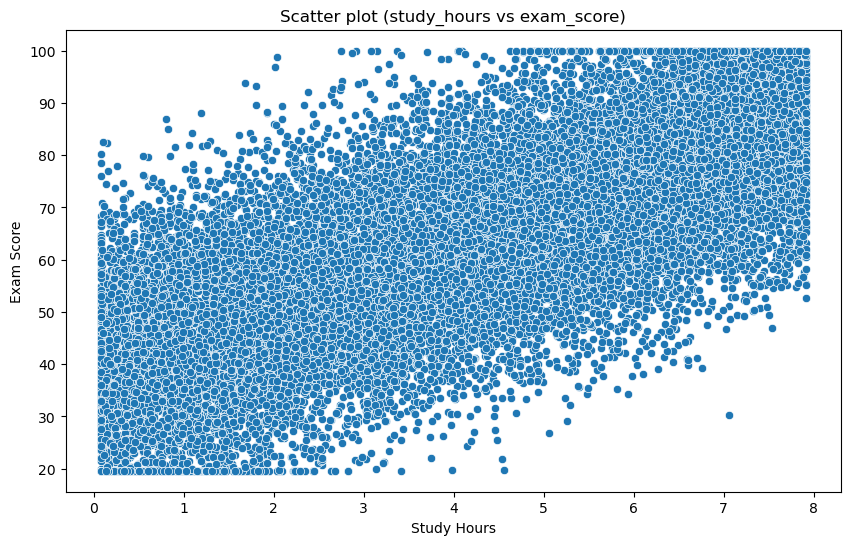

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
ax = sns.scatterplot(data=data, x='study_hours', y='exam_score')
ax.set_xlabel('Study Hours')
ax.set_ylabel('Exam Score')
ax.set_title('Scatter plot (study_hours vs exam_score)')
plt.show()

---
Bar visualization (Bar plot)
-

In bivariate analysis, bar plots are used to compare a numerical variable across different categories of a categorical variable. The categorical variable is shown on the x-axis, while the numeric variable is shown on the y-axis, often as an average or sum. This type of visualization allows us to easily see differences, trends, and patterns between groups, making it an essential tool for analyzing numerical–categorical relationships.

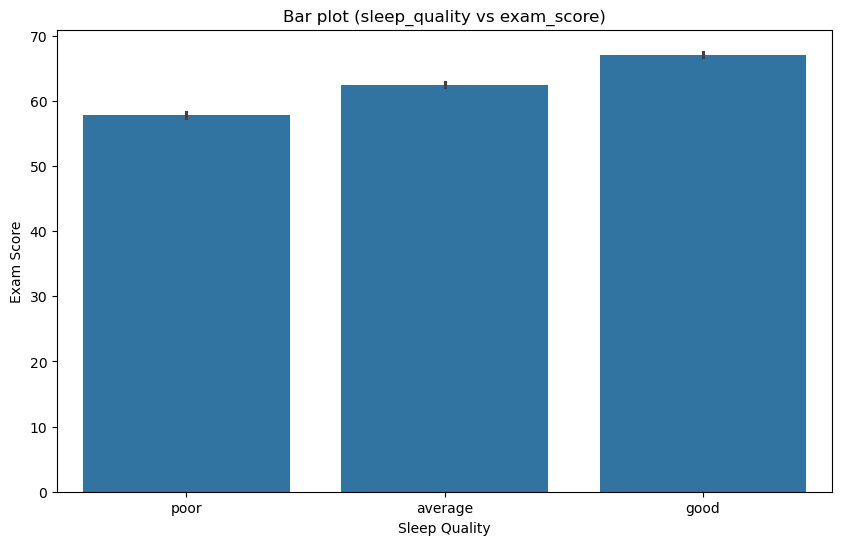

In [3]:
plt.figure(figsize=(10, 6))
ax = sns.barplot(data=data, x='sleep_quality', y='exam_score', estimator='mean')
ax.set_xlabel('Sleep Quality')
ax.set_ylabel('Exam Score')
ax.set_title('Bar plot (sleep_quality vs exam_score)')
plt.show()

---
Boxplot analysis
-

In previous course (day3_univariate_analysis) we used boxplot for univariate analysis to understand the distribution of a single numerical variable, where we saw median, quartiles, interquartile range (IQR), and outliers. However, in bivariate analysis, we usually use boxplot to examine how a numerical-variable varies across different categories of another variable. The difference is you're now comparing one numeric variable accross different categories, rather than just analyzing it alone.

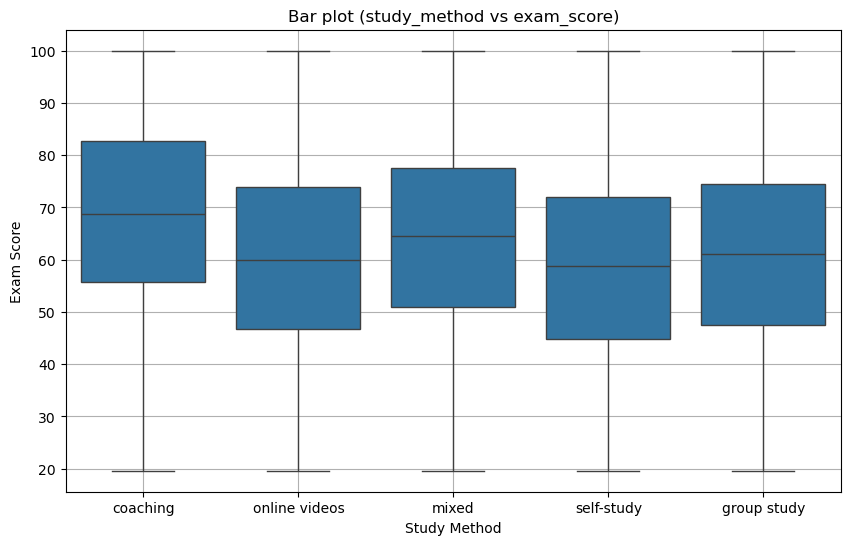

In [4]:
plt.figure(figsize=(10, 6))
ax = sns.boxplot(data=data, x='study_method', y='exam_score')
ax.set_xlabel('Study Method')
ax.set_ylabel('Exam Score')
ax.set_title('Bar plot (study_method vs exam_score)')
ax.grid(True) #Grid is applied for batter interpretation
plt.show()

From the boxplot above we can understand that the students who took a coaching scored best, while the student who took preparation through self study scored badly than other students who studied through online videos, mixed, group study etc

---

Two-way (crosstab) tables
-

A two-way table, also called a crosstab, is a tabular method to summarize the relationship between two categorical variables, where the rows represent categories of one variable, while the columns represent categories of another variable. Each cell shows the frequency (count) or proportion of observations that belong to the corresponding row-column combination. Essentially, crosstabs help us see how two categorical variables interact and whether certain combinations are more or less common.

In [5]:
crosstab = pd.crosstab(index=data['gender'], columns=data['exam_difficulty'])
print(crosstab)

exam_difficulty  easy  hard  moderate
gender                               
female           2025  1294      3260
male             2073  1305      3317
other            2043  1382      3301


---

Pivot-based Summary
-

A pivot table is a powerful tool to summarize, aggregate, and reorganize data in tabular form, often used to explore relationships between variables. Typically, one variable is placed along the rows, another along the columns, and an aggregation function (sum, mean, count, etc.) summarizes the data in the cells. Pivot tables can handle numeric variables grouped by categorical variables, making them ideal for bivariate summaries.Think of pivot tables as a more flexible, numerical version of a crosstab, often including metrics beyond simple counts.

In [6]:
pivot = pd.pivot_table(data, index='gender', values='exam_score', aggfunc='mean')
print(pivot)

        exam_score
gender            
female   62.582145
male     62.397480
other    62.561023


---

Pairplot
-

A pairplot provides a comprehensive visual overview of relationships between all numerical variables in a dataset. Off-diagonal scatterplots reveal pairwise relationships and potential correlations, while the diagonal histograms display the distribution of each variable. Pairplots are commonly used in exploratory data analysis to quickly identify patterns, correlations, and potential outliers across multiple variables.

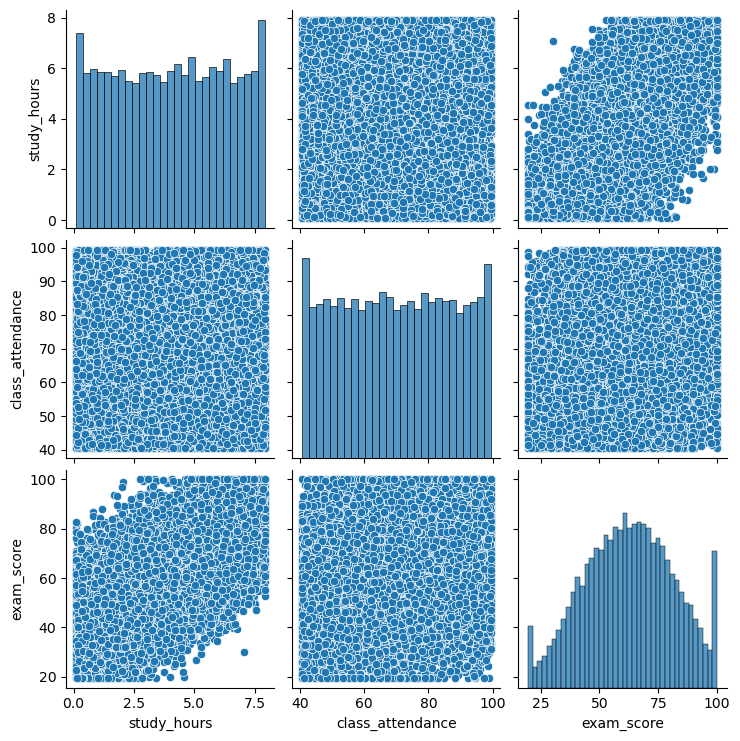

In [7]:
#data.drop(labels=['student_id'], axis=1, inplace=True)
#Let's select the numeric-columns in our dataset.
cols = data[['study_hours', 'class_attendance', 'exam_score']]
sns.pairplot(data=cols)
plt.show()

---

Compa histograms
-

Overlaid histograms allow us to compare the distributions of a numerical variable across different groups in a dataset. By plotting multiple groups on the same axis with distinct colors and transparency, we can visually assess differences in spread, central tendency, skewness, and outliers, making this a powerful tool for bivariate analysis between numeric and categorical variables.

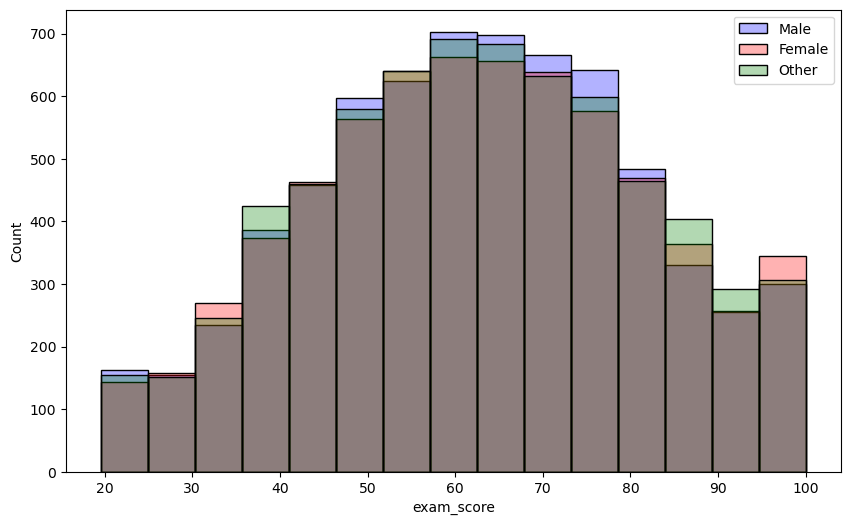

In [8]:
male_gender_data = data.loc[data['gender'] == 'male', :]
female_gender_data = data.loc[data['gender'] == 'female', :]
other_gender_data = data.loc[data['gender'] == 'other', :]

plt.figure(figsize=(10, 6))
ax = sns.histplot(data=male_gender_data, x='exam_score', bins=15, alpha=0.3, color='blue', label='Male')
ax = sns.histplot(data=female_gender_data, x='exam_score', bins=15, alpha=0.3, color='red', label='Female')
ax = sns.histplot(data=other_gender_data, x='exam_score', bins=15, alpha=0.3, color='green', label='Other')
plt.legend()

---

Correlation
-

Correlation quantifies the strength and direction of a linear relationship between two numerical variables. Values range from -1 (perfect negative) to +1 (perfect positive), with 0 indicating no linear association. Correlation is widely used in EDA to understand variable interactions, defect redundant features, and guide feature selection. Heatmap shows correlation coefficients for all numeric variables in a dataset. Highly correlated features may be redundant.

In [9]:
num_cols = data.select_dtypes(['int64', 'float64']).drop(labels=['student_id'], axis=1).columns.tolist()

<Axes: >

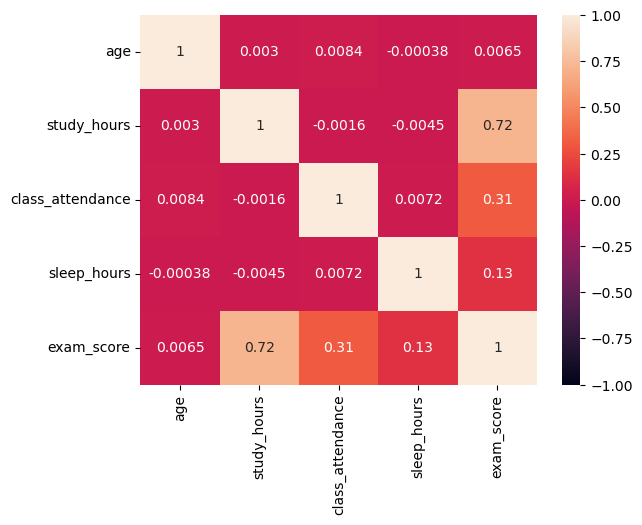

In [10]:
corr = data[num_cols].corr()
sns.heatmap(data=corr, annot=True, vmin=-1, vmax=1)

---